In [1]:
# ============================================================
# STEP 1. 라이브러리 불러오기
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import zipfile
import os
import glob

In [2]:
# ============================================================
# STEP 2. ZIP 압축 해제
# ============================================================

zip_path = "fraud_full_features.zip"
extract_path = "/content/fraud_data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("압축 해제 완료")

압축 해제 완료


In [3]:
# ============================================================
# STEP 3. CSV 자동 탐색 후 불러오기
# ============================================================

csv_files = glob.glob(
    os.path.join(extract_path, "**", "*.csv"),
    recursive=True
)

print("발견된 CSV:")
for file in csv_files:
    print(file)

if len(csv_files) == 0:
    raise FileNotFoundError("CSV 파일을 찾지 못했습니다.")

csv_path = csv_files[0]

df = pd.read_csv(csv_path)

print("\n데이터 크기:", df.shape)
display(df.head())

발견된 CSV:
/content/fraud_data/fraud_full_features.csv

데이터 크기: (1296675, 31)


,trans_date_trans_time,cc_num,merchant,category,amt,is_fraud,recent_24h_high_amt_count,category_recent_fraud_rate,category_recent_fraud_rate_missing,count_30min,...,amt_to_prior_median_ratio,is_10x_prior_median,has_prior_normal_transaction,outside_trans_hours_80,is_online,risk_time_22_04,interact_repeat_category,merchant_change_count,rolling_sum_amt_1h,is_high_amt
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,0,0,0.000000,0,0,...,NaN,0,0,0,1,0,0.0,0,7.27,0
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.94,0,0,0.006154,0,1,...,7.281981,0,1,0,0,0,0.0,1,52.94,0
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.08,0,0,0.006135,0,2,...,2.726457,0,1,0,0,0,0.0,1,135.02,0
3,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.79,0,0,0.000000,0,1,...,0.657159,0,1,0,0,0,0.0,1,34.79,0
4,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.18,0,0,0.000000,0,1,...,0.619628,0,1,0,0,0,0.0,1,61.97,0


In [4]:
df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"]
)

df = (
    df
    .sort_values("trans_date_trans_time")
    .reset_index(drop=True)
)

print("전체 거래 수:", f"{len(df):,}")
print("전체 fraud 수:", f"{df['is_fraud'].sum():,}")
print("전체 fraud rate:", f"{df['is_fraud'].mean():.4%}")

전체 거래 수: 1,296,675
전체 fraud 수: 7,506
전체 fraud rate: 0.5789%


In [5]:
# ============================================================
# STEP 4. 금액 구간별 사기율 확인
# ============================================================

print(df["amt"].describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.97,
        0.99,
        0.995,
        0.999
    ]
))

count    1.296675e+06
mean     7.035104e+01
std      1.603160e+02
min      1.000000e+00
50%      4.752000e+01
75%      8.314000e+01
90%      1.366700e+02
95%      1.963100e+02
97%      2.480678e+02
99%      5.459926e+02
99.5%    8.442226e+02
99.9%    1.499254e+03
max      2.894890e+04
Name: amt, dtype: float64


In [6]:
# ============================================================
# STEP 5. amt 분포 확인
# ============================================================

amt_bins = [
    0,
    50,
    100,
    200,
    300,
    400,
    500,
    600,
    700,
    800,
    900,
    1000,
    1500,
    2000,
    np.inf
]

amt_labels = [
    "0~50",
    "50~100",
    "100~200",
    "200~300",
    "300~400",
    "400~500",
    "500~600",
    "600~700",
    "700~800",
    "800~900",
    "900~1000",
    "1000~1500",
    "1500~2000",
    "2000+"
]

df["amt_bin"] = pd.cut(
    df["amt"],
    bins=amt_bins,
    labels=amt_labels,
    right=False
)

amt_fraud_summary = (
    df
    .groupby(
        "amt_bin",
        observed=True
    )
    .agg(
        transactions=("is_fraud", "size"),
        fraud_count=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

amt_fraud_summary["fraud_rate_pct"] = (
    amt_fraud_summary["fraud_rate"] * 100
)

display(
    amt_fraud_summary[
        [
            "amt_bin",
            "transactions",
            "fraud_count",
            "fraud_rate_pct"
        ]
    ].style.format({
        "fraud_rate_pct": "{:.2f}%"
    })
)

,amt_bin,transactions,fraud_count,fraud_rate_pct
0,0~50,672214,1607,0.24%
1,50~100,389514,45,0.01%
2,100~200,173017,150,0.09%
3,200~300,31631,795,2.51%
4,300~400,8600,1160,13.49%
5,400~500,6068,101,1.66%
6,500~600,4558,94,2.06%
7,600~700,1945,167,8.59%
8,700~800,1910,663,34.71%
9,800~900,1679,831,49.49%


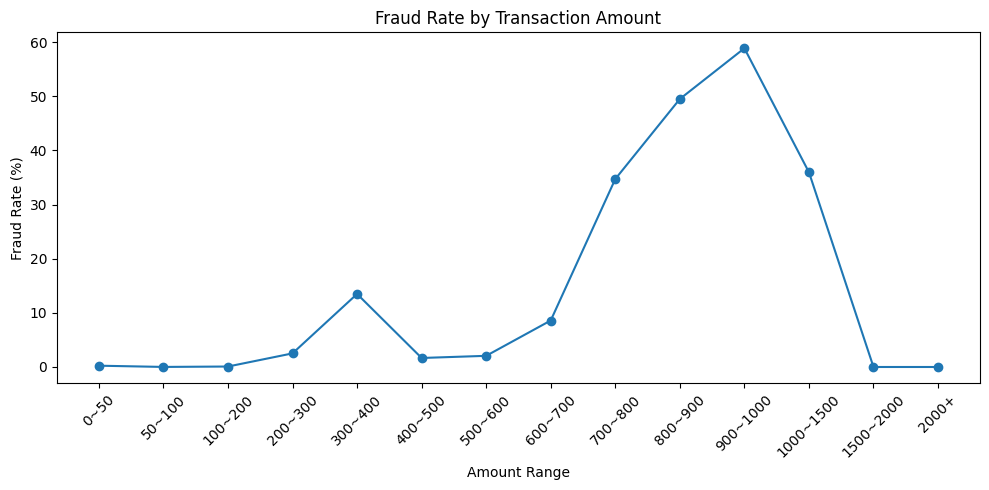

In [7]:
# ============================================================
# STEP 6. 금액별 사기율 그래프
# ============================================================


plt.figure(figsize=(10, 5))

plt.plot(
    amt_fraud_summary["amt_bin"].astype(str),
    amt_fraud_summary["fraud_rate_pct"],
    marker="o"
)

plt.xlabel("Amount Range")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Transaction Amount")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# STEP 7. “amt ≥ 기준” 누적 사기율 확인
# ============================================================


threshold_candidates = [
    300,
    400,
    500,
    600,
    700,
    800,
    900,
    1000,
    1200,
    1500,
    2000
]

threshold_results = []

total_fraud = df["is_fraud"].sum()

for threshold in threshold_candidates:

    high_amt_df = df[
        df["amt"] >= threshold
    ]

    transaction_count = len(high_amt_df)

    fraud_count = int(
        high_amt_df["is_fraud"].sum()
    )

    normal_count = (
        transaction_count
        - fraud_count
    )

    fraud_rate = (
        fraud_count / transaction_count
        if transaction_count > 0
        else np.nan
    )

    fraud_coverage = (
        fraud_count / total_fraud
        if total_fraud > 0
        else np.nan
    )

    threshold_results.append({
        "threshold": threshold,
        "transactions_above": transaction_count,
        "fraud_above": fraud_count,
        "normal_above": normal_count,
        "fraud_rate_above": fraud_rate,
        "fraud_coverage": fraud_coverage
    })


threshold_summary = pd.DataFrame(
    threshold_results
)

display(
    threshold_summary.style.format({
        "fraud_rate_above": "{:.2%}",
        "fraud_coverage": "{:.2%}"
    })
)

,threshold,transactions_above,fraud_above,normal_above,fraud_rate_above,fraud_coverage
0,300,30299,4909,25390,16.20%,65.40%
1,400,21699,3749,17950,17.28%,49.95%
2,500,15631,3648,11983,23.34%,48.60%
3,600,11073,3554,7519,32.10%,47.35%
4,700,9128,3387,5741,37.11%,45.12%
5,800,7218,2724,4494,37.74%,36.29%
6,900,5539,1893,3646,34.18%,25.22%
7,1000,3937,950,2987,24.13%,12.66%
8,1200,2166,57,2109,2.63%,0.76%
9,1500,1296,0,1296,0.00%,0.00%


amt가 높아질수록 Fraud가 계속 증가하는 구조가 아니야.

오히려:

$300 → $800까지 Fraud rate 증가
$800 부근에서 최고점(37.74%)
$900부터 감소
$1,200에서 2.63%
$1,500 이상에서는 Fraud 0건

이야.

따라서 우리가 처음 예상했던

amt ≥ $800 → 거의 Fraud → $800 이상을 Rule로 차단

이라는 가설은 현재 데이터에서 성립하지 않아.

$800 이상 7,218건 가운데 정상거래가 4,494건(약 62.3%)이나 있기 때문에 전부 차단하면 정상거래 오탐이 너무 많아.

In [14]:
# ============================================================
# STEP 7-1. fraud_full_features 데이터 다시 불러오기
# ============================================================

import pandas as pd
import numpy as np
import os
import glob

# 압축을 풀어놓은 폴더
extract_path = "/content/fraud_data"

# 폴더 안 CSV 파일 찾기
csv_files = glob.glob(
    os.path.join(extract_path, "**", "*.csv"),
    recursive=True
)

print("발견된 CSV 파일:")
for file in csv_files:
    print(file)

if len(csv_files) == 0:
    raise FileNotFoundError("CSV 파일을 찾지 못했습니다.")

# CSV 불러오기
fraud_full_features = pd.read_csv(csv_files[0])

print("\n데이터 불러오기 완료")
print("데이터 크기:", fraud_full_features.shape)

display(fraud_full_features.head())

발견된 CSV 파일:
/content/fraud_data/fraud_full_features.csv

데이터 불러오기 완료
데이터 크기: (1296675, 31)


,trans_date_trans_time,cc_num,merchant,category,amt,is_fraud,recent_24h_high_amt_count,category_recent_fraud_rate,category_recent_fraud_rate_missing,count_30min,...,amt_to_prior_median_ratio,is_10x_prior_median,has_prior_normal_transaction,outside_trans_hours_80,is_online,risk_time_22_04,interact_repeat_category,merchant_change_count,rolling_sum_amt_1h,is_high_amt
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,0,0,0.000000,0,0,...,NaN,0,0,0,1,0,0.0,0,7.27,0
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.94,0,0,0.006154,0,1,...,7.281981,0,1,0,0,0,0.0,1,52.94,0
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.08,0,0,0.006135,0,2,...,2.726457,0,1,0,0,0,0.0,1,135.02,0
3,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.79,0,0,0.000000,0,1,...,0.657159,0,1,0,0,0,0.0,1,34.79,0
4,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.18,0,0,0.000000,0,1,...,0.619628,0,1,0,0,0,0.0,1,61.97,0


In [15]:
# ============================================================
# STEP 7-2. Rule 분석에 필요한 변수 확인
# ============================================================

required_columns = [
    "amt",
    "is_fraud"
]

missing_columns = [
    col
    for col in required_columns
    if col not in fraud_full_features.columns
]

if missing_columns:
    raise ValueError(
        f"필요한 변수가 없습니다: {missing_columns}"
    )

print("필수 변수 확인 완료")
print("전체 거래 수:", f"{len(fraud_full_features):,}")
print("전체 Fraud 수:", f"{fraud_full_features['is_fraud'].sum():,.0f}")
print("전체 Fraud Rate:", f"{fraud_full_features['is_fraud'].mean():.4%}")

필수 변수 확인 완료
전체 거래 수: 1,296,675
전체 Fraud 수: 7,506
전체 Fraud Rate: 0.5789%


In [17]:
# ============================================================
# STEP 8. 고액거래 상한 Rule 설정
# ============================================================

AMT_LIMIT = 800

print(f"1차 고액거래 Rule: amt >= ${AMT_LIMIT}")
print(f"2차 LightGBM 대상: amt < ${AMT_LIMIT}")

1차 고액거래 Rule: amt >= $800
2차 LightGBM 대상: amt < $800


Fraud를 최대한 많이 1차에서 제거하는 것이 중요하다면 사실 $700도 강력한 후보야.

하지만 너희 프로젝트 목적을 고려하면 나는 $800을 추천해.

왜냐하면 지금 목적이 사기 탐지 Rule 자체를 최적화하는 게 아니라,

너무 명백한 고액 패턴을 1차적으로 제거하고 → 남은 애매한 거래에서 새로운 행동 패턴을 LightGBM으로 찾는다

이기 때문이야.

그리고 STEP 7에서 Fraud Rate가 $800에서 37.74%로 정점을 찍은 뒤 감소하기 시작한다는 점도 $800을 설명하기 좋은 근거가 돼.

발표에서는 이렇게 설명하면 깔끔해.

고액거래 상한 기준을 설정하기 위해 금액 threshold별 Fraud Rate와 Fraud Coverage를 비교하였다. $800 이상에서 Fraud Rate가 37.74%로 가장 높았으며 전체 Fraud의 36.29%가 해당 구간에 포함되었다. $900 이상부터는 Fraud Rate와 Fraud Coverage가 모두 감소하였다. 따라서 본 데이터에서는 $800을 고액거래에 대한 1차 Rule-based screening 기준으로 설정하고, $800 이상 거래를 모델 학습 대상에서 분리하였다. 이후 $800 미만 거래를 대상으로 금액만으로 설명하기 어려운 이상거래 패턴을 탐색하였다.

다만 “$800 이상이면 사기이기 때문에 제거했다”라고 쓰면 안 돼. 실제 사기율은 37.74%니까 정상거래가 더 많아. 정확한 표현은 “오탐을 허용하는 정책적 상한 Rule로 설정했다”야.

In [18]:
# ============================================================
# STEP 9. Rule 대상 거래와 LightGBM 모델링 대상 거래 분리
# ============================================================

# 1차 Rule에서 배제되는 고액거래
fraud_rule_excluded = fraud_full_features[
    fraud_full_features["amt"] >= AMT_LIMIT
].copy()

# 2차 LightGBM 모델에 사용할 거래
fraud_model_data = fraud_full_features[
    fraud_full_features["amt"] < AMT_LIMIT
].copy()


print("===== 전체 원본 데이터 =====")
print(f"전체 거래 수: {len(fraud_full_features):,}")
print(f"전체 Fraud 수: {int(fraud_full_features['is_fraud'].sum()):,}")
print(f"전체 Fraud Rate: {fraud_full_features['is_fraud'].mean():.4%}")


print("\n===== 1차 Rule 대상 거래 =====")
print(f"거래 수: {len(fraud_rule_excluded):,}")
print(f"Fraud 수: {int(fraud_rule_excluded['is_fraud'].sum()):,}")
print(f"Normal 수: {int((fraud_rule_excluded['is_fraud'] == 0).sum()):,}")
print(f"Fraud Rate: {fraud_rule_excluded['is_fraud'].mean():.2%}")


print("\n===== 2차 LightGBM 모델링 대상 =====")
print(f"거래 수: {len(fraud_model_data):,}")
print(f"Fraud 수: {int(fraud_model_data['is_fraud'].sum()):,}")
print(f"Normal 수: {int((fraud_model_data['is_fraud'] == 0).sum()):,}")
print(f"Fraud Rate: {fraud_model_data['is_fraud'].mean():.4%}")

===== 전체 원본 데이터 =====
전체 거래 수: 1,296,675
전체 Fraud 수: 7,506
전체 Fraud Rate: 0.5789%

===== 1차 Rule 대상 거래 =====
거래 수: 7,218
Fraud 수: 2,724
Normal 수: 4,494
Fraud Rate: 37.74%

===== 2차 LightGBM 모델링 대상 =====
거래 수: 1,289,457
Fraud 수: 4,782
Normal 수: 1,284,675
Fraud Rate: 0.3709%


In [19]:
# ============================================================
# STEP 10. Rule 적용 결과 검증
# ============================================================

# 전체 데이터 = Rule 대상 + 모델링 대상인지 확인
assert len(fraud_full_features) == (
    len(fraud_rule_excluded)
    + len(fraud_model_data)
)

# Rule 대상에는 $800 이상만 존재하는지 확인
assert (
    fraud_rule_excluded["amt"] >= AMT_LIMIT
).all()

# 모델 데이터에는 $800 미만만 존재하는지 확인
assert (
    fraud_model_data["amt"] < AMT_LIMIT
).all()

print("✅ Rule 분리 검증 완료")
print(
    f"${AMT_LIMIT} 이상 거래는 모두 1차 Rule 대상으로 분리되었고,"
)
print(
    f"${AMT_LIMIT} 미만 거래만 LightGBM 모델링 데이터에 남았습니다."
)

✅ Rule 분리 검증 완료
$800 이상 거래는 모두 1차 Rule 대상으로 분리되었고,
$800 미만 거래만 LightGBM 모델링 데이터에 남았습니다.


In [20]:
# ============================================================
# STEP 11. 1차 Rule의 사기 탐지 효과 확인
# ============================================================

total_fraud = int(
    fraud_full_features["is_fraud"].sum()
)

rule_fraud = int(
    fraud_rule_excluded["is_fraud"].sum()
)

rule_normal = int(
    (fraud_rule_excluded["is_fraud"] == 0).sum()
)

rule_transactions = len(
    fraud_rule_excluded
)

fraud_rate = (
    rule_fraud / rule_transactions
)

fraud_coverage = (
    rule_fraud / total_fraud
)


rule_summary = pd.DataFrame({
    "Metric": [
        "전체 Fraud",
        "Rule 대상 거래",
        "Rule 대상 Fraud",
        "Rule 대상 Normal",
        "Rule Fraud Rate",
        "Fraud Coverage"
    ],
    "Value": [
        total_fraud,
        rule_transactions,
        rule_fraud,
        rule_normal,
        fraud_rate,
        fraud_coverage
    ]
})

display(rule_summary)

print(
    f"\nRule Fraud Rate: {fraud_rate:.2%}"
)

print(
    f"Fraud Coverage: {fraud_coverage:.2%}"
)

,Metric,Value
0,전체 Fraud,7506.00000
1,Rule 대상 거래,7218.00000
2,Rule 대상 Fraud,2724.00000
3,Rule 대상 Normal,4494.00000
4,Rule Fraud Rate,0.37739
5,Fraud Coverage,0.36291



Rule Fraud Rate: 37.74%
Fraud Coverage: 36.29%


Rule Fraud Rate = $800 이상 거래 중 실제 Fraud 비율
Fraud Coverage = 전체 Fraud 중 $800 이상 Rule에서 먼저 분리되는 Fraud 비율

In [21]:
# ============================================================
# STEP 12. Rule 적용 전후 amt 분포 비교
# ============================================================

comparison = pd.DataFrame({
    "원본 데이터": fraud_full_features["amt"].describe(),
    "Rule 적용 후": fraud_model_data["amt"].describe()
})

display(comparison)

print(
    "\nRule 적용 후 최대 amt:",
    fraud_model_data["amt"].max()
)

,원본 데이터,Rule 적용 후
count,1.296675e+06,1.289457e+06
mean,7.035104e+01,6.306177e+01
std,1.603160e+02,7.785030e+01
min,1.000000e+00,1.000000e+00
25%,9.650000e+00,9.600000e+00
50%,4.752000e+01,4.714000e+01
75%,8.314000e+01,8.233000e+01
max,2.894890e+04,7.999500e+02



Rule 적용 후 최대 amt: 799.95


현재 $800 상한 Rule을 적용한 결과는 다음과 같아.

전체 거래: 1,296,675건
전체 Fraud: 7,506건
amt >= 800 Rule 대상: 7,218건
그중 Fraud: 2,724건
그중 Normal: 4,494건
Rule Fraud Rate: 37.74%
Fraud Coverage: 36.29%
Rule 적용 후 LightGBM 대상: 1,289,457건
남은 Fraud: 4,782건
남은 데이터의 Fraud Rate: 0.3709%
Rule 적용 후 최대 amt: 799.95

즉 전체 Fraud 7,506건 중 2,724건, 약 36.3%를 1차 금액 Rule에서 분리했고, 남은 4,782건의 Fraud를 이후 LightGBM이 탐지해야 하는 구조가 된 거야.

또 amt 평균이 약 70.35 → 63.06, 표준편차가 약 160.32 → 77.85로 크게 줄었어. 즉 초고액 거래가 빠지면서 금액 분포의 극단성이 상당히 완화됐다는 것도 확인돼.

In [22]:
# ============================================================
# STEP 13. 기존 조합3 변수 및 LightGBM 고정 설정 정의
# ============================================================

import numpy as np
import pandas as pd

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 기본 설정
# ------------------------------------------------------------

TARGET = "is_fraud"
TIME_COL = "trans_date_trans_time"

RANDOM_STATE = 42
EARLY_STOPPING_ROUNDS = 100

# 기존 OOF 운영 임계값
FIXED_THRESHOLD = 0.928939


# ------------------------------------------------------------
# 기존 조합 3 : 11개 변수
# ------------------------------------------------------------

FEATURES = [
    "category",
    "amt",
    "trans_hour",
    "age",
    "recent_24h_high_amt_count",
    "amt_to_prior_median_ratio",
    "rolling_sum_amt_1h",
    "amt_zscore_card",
    "prior_normal_median_amt",
    "count_30min",
    "high_speed"
]

CATEGORICAL_FEATURES = [
    "category"
]


# ------------------------------------------------------------
# 기존 조합3 최종 LightGBM 설정
# 기존 노트북의 최종값과 반드시 동일한지 확인
# ------------------------------------------------------------

LGBM_PARAMS = {
    "objective": "binary",
    "boosting_type": "gbdt",

    # early stopping을 위한 충분한 최대 트리 수
    "n_estimators": 2500,

    "learning_rate": 0.03,

    "num_leaves": 23,
    "max_depth": 5,
    "min_child_samples": 150,

    "subsample": 0.9,
    "subsample_freq": 1,
    "colsample_bytree": 0.9,

    "reg_alpha": 0.1,
    "reg_lambda": 1.0,

    "min_split_gain": 0.0,
    "max_bin": 255,

    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1
}


print("===== STEP 13 설정 확인 =====")
print("사용 변수 수:", len(FEATURES))
print("기존 비교용 Threshold:", FIXED_THRESHOLD)

print("\n사용 변수")
for i, feature in enumerate(FEATURES, start=1):
    print(f"{i:2d}. {feature}")

print("\nLightGBM 설정")
for key, value in LGBM_PARAMS.items():
    print(f"{key}: {value}")

===== STEP 13 설정 확인 =====
사용 변수 수: 11
기존 비교용 Threshold: 0.928939

사용 변수
 1. category
 2. amt
 3. trans_hour
 4. age
 5. recent_24h_high_amt_count
 6. amt_to_prior_median_ratio
 7. rolling_sum_amt_1h
 8. amt_zscore_card
 9. prior_normal_median_amt
10. count_30min
11. high_speed

LightGBM 설정
objective: binary
boosting_type: gbdt
n_estimators: 2500
learning_rate: 0.03
num_leaves: 23
max_depth: 5
min_child_samples: 150
subsample: 0.9
subsample_freq: 1
colsample_bytree: 0.9
reg_alpha: 0.1
reg_lambda: 1.0
min_split_gain: 0.0
max_bin: 255
random_state: 42
n_jobs: -1
verbosity: -1


| 항목           | 설정                                  |
| ------------ | ----------------------------------- |
| 모델           | LightGBM                            |
| 데이터          | `fraud_model_data` (`amt < 800`)    |
| 변수           | 조합3 11개에서 시작                        |
| CV           | 기존과 동일한 Expanding Window 3-Fold     |
| 불균형 처리       | `scale_pos_weight = normal / fraud` |
| Threshold    | **0.928939**                        |
| Random state | 42                                  |
| 평가 중심        | PR-AUC                              |
| 기타           | 기존 LightGBM 최종 하이퍼파라미터 유지           |


In [23]:
# ============================================================
# STEP 13-1. Rule 적용 후 모델링 데이터 검증
# ============================================================

required_columns = FEATURES + [
    TARGET,
    TIME_COL
]

missing_columns = [
    col
    for col in required_columns
    if col not in fraud_model_data.columns
]

if missing_columns:
    raise ValueError(
        f"fraud_model_data에 없는 변수: {missing_columns}"
    )


assert (
    fraud_model_data["amt"] < 800
).all()


print("✅ 필수 변수 확인 완료")
print("✅ amt < $800 조건 확인 완료")

print(
    "모델링 대상 거래:",
    f"{len(fraud_model_data):,}"
)

print(
    "남은 Fraud:",
    f"{int(fraud_model_data[TARGET].sum()):,}"
)

print(
    "Fraud Rate:",
    f"{fraud_model_data[TARGET].mean():.4%}"
)

print(
    "최대 amt:",
    fraud_model_data["amt"].max()
)

✅ 필수 변수 확인 완료
✅ amt < $800 조건 확인 완료
모델링 대상 거래: 1,289,457
남은 Fraud: 4,782
Fraud Rate: 0.3709%
최대 amt: 799.95


STEP 12
$800 이상 거래 제거 완료
        ↓
STEP 13
조합3 변수 + LightGBM 고정 설정
        ↓
STEP 14
시간순 정렬 및 데이터 확인
        ↓
STEP 15
Expanding Window 3-Fold
        ↓
STEP 16
Fold 데이터 준비
        ↓
STEP 17
LightGBM 학습
각 Fold에서 scale_pos_weight = Normal / Fraud
        ↓
STEP 18
OOF PR-AUC 확인
        ↓
STEP 19~
SHAP 중요도 분석

In [24]:
# ============================================================
# STEP 13. 기존 조합3 변수 정의
# ============================================================

TARGET = "is_fraud"
TIME_COL = "trans_date_trans_time"

FEATURES = [
    "category",
    "amt",
    "trans_hour",
    "age",
    "recent_24h_high_amt_count",
    "amt_to_prior_median_ratio",
    "rolling_sum_amt_1h",
    "amt_zscore_card",
    "prior_normal_median_amt",
    "count_30min",
    "high_speed"
]

CATEGORICAL_FEATURES = [
    "category"
]

print("사용 변수 수:", len(FEATURES))
print(FEATURES)

사용 변수 수: 11
['category', 'amt', 'trans_hour', 'age', 'recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'amt_zscore_card', 'prior_normal_median_amt', 'count_30min', 'high_speed']


In [25]:
# ============================================================
# STEP 14. Rule 적용 후 데이터 시간순 정렬 및 기본 확인
# ============================================================

fraud_model_data[TIME_COL] = pd.to_datetime(
    fraud_model_data[TIME_COL]
)

fraud_model_data = (
    fraud_model_data
    .sort_values(TIME_COL)
    .reset_index(drop=True)
)

print("모델링 대상 거래 수:", f"{len(fraud_model_data):,}")
print("Fraud 수:", f"{fraud_model_data[TARGET].sum():,}")
print("Fraud Rate:", f"{fraud_model_data[TARGET].mean():.4%}")

print(
    "기간:",
    fraud_model_data[TIME_COL].min(),
    "~",
    fraud_model_data[TIME_COL].max()
)

모델링 대상 거래 수: 1,289,457
Fraud 수: 4,782
Fraud Rate: 0.3709%
기간: 2019-01-01 00:00:18 ~ 2020-06-21 12:13:37


In [26]:
# ============================================================
# STEP 15. Expanding Window 3-Fold 생성
# ============================================================

import numpy as np

n_rows = len(fraud_model_data)

boundaries = np.linspace(
    0,
    n_rows,
    7,
    dtype=int
)

time_folds = []

for fold_number in range(1, 4):

    train_end = boundaries[fold_number + 2]
    val_start = train_end
    val_end = boundaries[fold_number + 3]

    time_folds.append({
        "fold": fold_number,
        "train_idx": np.arange(0, train_end),
        "val_idx": np.arange(val_start, val_end)
    })


for fold in time_folds:

    print(
        f"Fold {fold['fold']} | "
        f"Train={len(fold['train_idx']):,} | "
        f"Validation={len(fold['val_idx']):,}"
    )

Fold 1 | Train=644,728 | Validation=214,910
Fold 2 | Train=859,638 | Validation=214,909
Fold 3 | Train=1,074,547 | Validation=214,910


In [27]:
# ============================================================
# STEP 16. Fold별 학습/검증 데이터 준비 함수
# ============================================================

def prepare_fold_data(
    source_data,
    train_indices,
    val_indices
):

    X_train = (
        source_data
        .iloc[train_indices][FEATURES]
        .copy()
        .reset_index(drop=True)
    )

    X_val = (
        source_data
        .iloc[val_indices][FEATURES]
        .copy()
        .reset_index(drop=True)
    )

    y_train = (
        source_data
        .iloc[train_indices][TARGET]
        .astype(np.int8)
        .reset_index(drop=True)
    )

    y_val = (
        source_data
        .iloc[val_indices][TARGET]
        .astype(np.int8)
        .reset_index(drop=True)
    )

    for col in CATEGORICAL_FEATURES:

        train_categories = (
            X_train[col]
            .astype("string")
            .fillna("missing")
            .unique()
            .tolist()
        )

        X_train[col] = pd.Categorical(
            X_train[col]
            .astype("string")
            .fillna("missing"),
            categories=train_categories
        )

        X_val[col] = pd.Categorical(
            X_val[col]
            .astype("string")
            .fillna("missing"),
            categories=train_categories
        )

    return X_train, X_val, y_train, y_val

In [28]:
# ============================================================
# STEP 17. Rule 적용 후 조합3 LightGBM Baseline 학습
# ============================================================

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

BEST_LGBM_PARAMS = {
    "num_leaves": 23,
    "max_depth": 5,
    "min_child_samples": 150,
    "learning_rate": 0.03,
    "subsample": 0.9,
    "subsample_freq": 1,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "min_split_gain": 0.0,
    "max_bin": 255
}

RANDOM_STATE = 42
EARLY_STOPPING_ROUNDS = 100

oof_parts = []
fold_results = []
fold_models = []

for fold_info in time_folds:

    fold_number = fold_info["fold"]

    train_idx = fold_info["train_idx"]
    val_idx = fold_info["val_idx"]

    X_train, X_val, y_train, y_val = prepare_fold_data(
        source_data=fraud_model_data,
        train_indices=train_idx,
        val_indices=val_idx
    )

    negative_count = int(
        (y_train == 0).sum()
    )

    positive_count = int(
        (y_train == 1).sum()
    )

    scale_pos_weight = (
        negative_count / positive_count
    )

    model = LGBMClassifier(
        objective="binary",
        n_estimators=2500,
        **BEST_LGBM_PARAMS,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="average_precision",
        categorical_feature=CATEGORICAL_FEATURES,
        callbacks=[
            early_stopping(
                stopping_rounds=EARLY_STOPPING_ROUNDS,
                first_metric_only=True,
                verbose=False
            ),
            log_evaluation(period=0)
        ]
    )

    val_prob = model.predict_proba(
        X_val,
        num_iteration=model.best_iteration_
    )[:, 1]

    fold_pr_auc = average_precision_score(
        y_val,
        val_prob
    )

    fold_results.append({
        "Fold": fold_number,
        "Train": len(X_train),
        "Validation": len(X_val),
        "Best Iteration": model.best_iteration_,
        "PR-AUC": fold_pr_auc
    })

    oof_parts.append(
        pd.DataFrame({
            "original_index": val_idx,
            "fold": fold_number,
            "y_true": y_val.to_numpy(),
            "y_prob": val_prob
        })
    )

    fold_models.append(model)

    print(
        f"Fold {fold_number} 완료 | "
        f"PR-AUC={fold_pr_auc:.6f} | "
        f"Best Iteration={model.best_iteration_}"
    )

Fold 1 완료 | PR-AUC=0.955888 | Best Iteration=1930
Fold 2 완료 | PR-AUC=0.967236 | Best Iteration=1841
Fold 3 완료 | PR-AUC=0.959085 | Best Iteration=1616


In [29]:
# ============================================================
# STEP 18. Rule 적용 후 Baseline PR-AUC 확인
# ============================================================

fold_result_df = pd.DataFrame(
    fold_results
)

display(fold_result_df)

oof_data = (
    pd.concat(
        oof_parts,
        ignore_index=True
    )
    .sort_values("original_index")
    .reset_index(drop=True)
)

oof_pr_auc = average_precision_score(
    oof_data["y_true"],
    oof_data["y_prob"]
)

print(
    "\n전체 OOF PR-AUC:",
    f"{oof_pr_auc:.6f}"
)

print(
    "Fold 평균 PR-AUC:",
    f"{fold_result_df['PR-AUC'].mean():.6f}"
)

print(
    "Fold PR-AUC 표준편차:",
    f"{fold_result_df['PR-AUC'].std():.6f}"
)

,Fold,Train,Validation,Best Iteration,PR-AUC
0,1,644728,214910,1930,0.955888
1,2,859638,214909,1841,0.967236
2,3,1074547,214910,1616,0.959085



전체 OOF PR-AUC: 0.960787
Fold 평균 PR-AUC: 0.960736
Fold PR-AUC 표준편차: 0.005851


In [35]:
# ============================================================
# STEP 19. SHAP 분석용 대표 표본 준비
# ============================================================

import shap

SHAP_SAMPLE_SIZE = 30000

shap_source = fraud_model_data[
    FEATURES
].copy()

if len(shap_source) > SHAP_SAMPLE_SIZE:

    shap_sample = shap_source.sample(
        n=SHAP_SAMPLE_SIZE,
        random_state=42
    ).copy()

else:

    shap_sample = shap_source.copy()


for col in CATEGORICAL_FEATURES:

    categories = (
        shap_sample[col]
        .astype("string")
        .fillna("missing")
        .unique()
        .tolist()
    )

    shap_sample[col] = pd.Categorical(
        shap_sample[col]
        .astype("string")
        .fillna("missing"),
        categories=categories
    )

print("SHAP 표본 수:", len(shap_sample))

SHAP 표본 수: 30000


In [34]:
# ============================================================
# STEP 20. SHAP 해석용 전체 모델 학습
# ============================================================

X_full = fraud_model_data[
    FEATURES
].copy()

y_full = fraud_model_data[
    TARGET
].astype(np.int8)

for col in CATEGORICAL_FEATURES:

    categories = (
        X_full[col]
        .astype("string")
        .fillna("missing")
        .unique()
        .tolist()
    )

    X_full[col] = pd.Categorical(
        X_full[col]
        .astype("string")
        .fillna("missing"),
        categories=categories
    )

    shap_sample[col] = pd.Categorical(
        shap_sample[col]
        .astype("string")
        .fillna("missing"),
        categories=categories
    )


negative_count = int(
    (y_full == 0).sum()
)

positive_count = int(
    (y_full == 1).sum()
)

scale_pos_weight_full = (
    negative_count / positive_count
)

best_iteration_mean = int(
    fold_result_df[
        "Best Iteration"
    ].mean()
)

shap_model = LGBMClassifier(
    objective="binary",
    n_estimators=best_iteration_mean,
    **BEST_LGBM_PARAMS,
    scale_pos_weight=scale_pos_weight_full,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

shap_model.fit(
    X_full,
    y_full,
    categorical_feature=CATEGORICAL_FEATURES
)

print(
    "SHAP 모델 학습 완료 | "
    f"n_estimators={best_iteration_mean}"
)

SHAP 모델 학습 완료 | n_estimators=1795


In [36]:
# ============================================================
# STEP 21. 11개 변수 SHAP 중요도 계산
# ============================================================

explainer = shap.TreeExplainer(
    shap_model
)

shap_values = explainer.shap_values(
    shap_sample
)

# binary classification에서
# list 형태로 반환될 경우 fraud class(1) 사용
if isinstance(shap_values, list):
    shap_matrix = shap_values[1]
else:
    shap_matrix = shap_values


shap_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Mean_ABS_SHAP": np.abs(
        shap_matrix
    ).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "Mean_ABS_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(shap_importance)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,Feature,Mean_ABS_SHAP
0,category,2.739602
1,amt,0.955476
2,trans_hour,0.740442
3,age,0.736437
4,rolling_sum_amt_1h,0.719782
5,prior_normal_median_amt,0.560853
6,amt_to_prior_median_ratio,0.470033
7,amt_zscore_card,0.356174
8,recent_24h_high_amt_count,0.131761
9,high_speed,0.129396


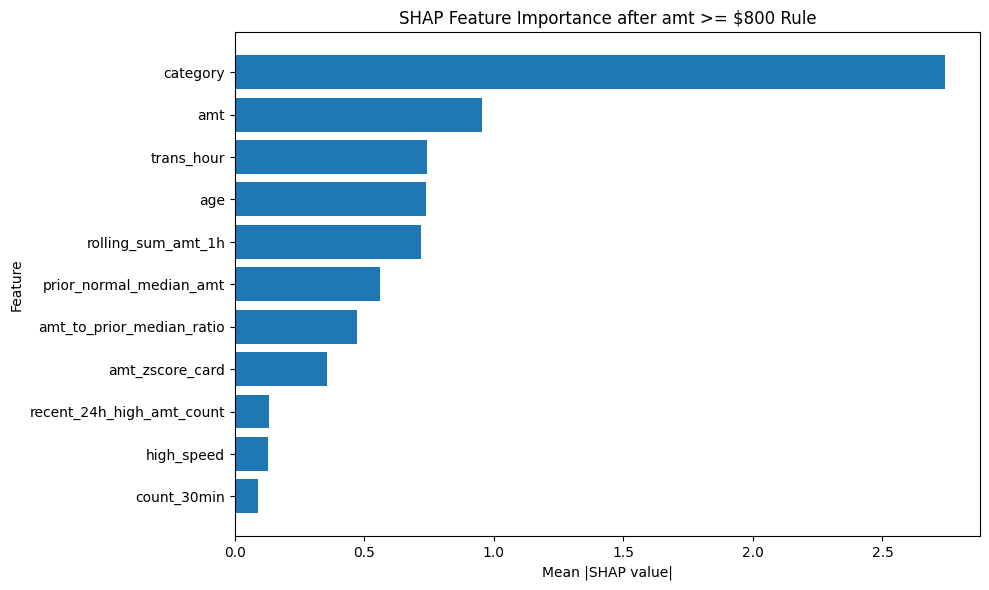

In [37]:
# ============================================================
# STEP 22. SHAP 중요도 시각화
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    shap_importance["Feature"][::-1],
    shap_importance["Mean_ABS_SHAP"][::-1]
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title(
    "SHAP Feature Importance after amt >= $800 Rule"
)

plt.tight_layout()
plt.show()

#
| 순위 | 변수                          | Mean (SHAP) | 지금 판단        |
| -: | --------------------------- | ----------: | ------------ |
|  1 | `category`                  |  **2.7396** | 🔴 최우선 조사    |
|  2 | `amt`                       |  **0.9555** | 🔴 제거 실험 우선  |
|  3 | `trans_hour`                |      0.7404 | 🟡 유지 우선     |
|  4 | `age`                       |      0.7364 | 🟠 제거 검토     |
|  5 | `rolling_sum_amt_1h`        |      0.7198 | 🟡 유지 우선     |
|  6 | `prior_normal_median_amt`   |      0.5609 | 🟡 유지 우선     |
|  7 | `amt_to_prior_median_ratio` |      0.4700 | 🟡 유지 우선     |
|  8 | `amt_zscore_card`           |      0.3562 | 🟡 유지 우선     |
|  9 | `recent_24h_high_amt_count` |      0.1318 | 🟢 유지        |
| 10 | `high_speed`                |      0.1294 | 🟢 유지        |
| 11 | `count_30min`               |      0.0909 | 🟠 나중에 제거 검토 |


#① category 원자료 분석 → ② amt 제거 실험 → ③ age 제거 실험 → ④ 필요하면 amt + age 동시 제거 → ⑤ 남은 모델 SHAP 재계산

In [38]:
# ============================================================
# STEP 23. category별 거래 수와 Fraud Rate 확인
# ============================================================

category_analysis = (
    fraud_model_data
    .groupby(
        "category",
        observed=True
    )
    .agg(
        transactions=("is_fraud", "size"),
        fraud_count=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

category_analysis["normal_count"] = (
    category_analysis["transactions"]
    - category_analysis["fraud_count"]
)

category_analysis["fraud_rate_pct"] = (
    category_analysis["fraud_rate"] * 100
)

category_analysis = (
    category_analysis
    .sort_values(
        "fraud_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    category_analysis[
        [
            "category",
            "transactions",
            "fraud_count",
            "normal_count",
            "fraud_rate_pct"
        ]
    ].style.format({
        "fraud_rate_pct": "{:.3f}%"
    })
)

,category,transactions,fraud_count,normal_count,fraud_rate_pct
0,grocery_pos,123638,1743,121895,1.410%
1,misc_net,62412,494,61918,0.792%
2,gas_transport,131659,618,131041,0.469%
3,grocery_net,45452,134,45318,0.295%
4,travel,39964,116,39848,0.290%
5,misc_pos,79162,218,78944,0.275%
6,entertainment,94012,233,93779,0.248%
7,personal_care,90758,220,90538,0.242%
8,shopping_pos,114315,256,114059,0.224%
9,kids_pets,113035,239,112796,0.211%


In [39]:
# ============================================================
# STEP 24. category별 전체 Fraud 기여 비중 확인
# ============================================================

total_fraud_after_rule = (
    fraud_model_data["is_fraud"].sum()
)

category_analysis["fraud_coverage"] = (
    category_analysis["fraud_count"]
    / total_fraud_after_rule
)

display(
    category_analysis[
        [
            "category",
            "transactions",
            "fraud_count",
            "fraud_rate_pct",
            "fraud_coverage"
        ]
    ].style.format({
        "fraud_rate_pct": "{:.3f}%",
        "fraud_coverage": "{:.2%}"
    })
)

,category,transactions,fraud_count,fraud_rate_pct,fraud_coverage
0,grocery_pos,123638,1743,1.410%,36.45%
1,misc_net,62412,494,0.792%,10.33%
2,gas_transport,131659,618,0.469%,12.92%
3,grocery_net,45452,134,0.295%,2.80%
4,travel,39964,116,0.290%,2.43%
5,misc_pos,79162,218,0.275%,4.56%
6,entertainment,94012,233,0.248%,4.87%
7,personal_care,90758,220,0.242%,4.60%
8,shopping_pos,114315,256,0.224%,5.35%
9,kids_pets,113035,239,0.211%,5.00%


category는 제거하지 않는 쪽이 더 타당해 보여. SHAP 중요도는 압도적으로 높았지만, 원자료를 확인해보니 amt ≥ 800처럼 특정 값 하나가 Fraud를 거의 확정적으로 가르는 변수는 아니기 때문이야.

grocery_pos가 가장 위험하지만 Fraud rate는 **1.410%** 야. 즉 이 업종 거래 123,368건 가운데 Fraud는 1,743건이고 정상은 121,895건이야. grocery_pos라는 이유만으로 거래를 차단할 수 있는 수준은 아니지. 반면 전체 Fraud 중에서는 **36.45%** 가 이 업종에서 발생하고 있어.

또 misc_net은 Fraud rate 0.792%, coverage 10.33%, gas_transport는 Fraud rate 0.469%, coverage 12.92%로 나타났어. 반대로 shopping_net은 거래가 94,595건이나 있는데 Fraud rate가 **0.031%** 에 불과해.

이 결과가 오히려 category의 높은 SHAP을 설명해줘.

업종별 Fraud 발생확률의 차이가 상당히 크기 때문에 LightGBM이 category를 적극적으로 활용하고 있지만, 어느 category도 그 자체만으로 Fraud 여부를 결정하지는 않는다.

즉 category는 “너무 뻔해서 제거해야 하는 변수”라기보다 다른 행동변수와 결합해서 Fraud 위험도를 구분하는 유용한 정보일 가능성이 높아.

In [40]:
# ============================================================
# STEP 25. Rule 적용 후 amt 구간별 Fraud Rate 확인
# ============================================================

amt_bins_after_rule = [
    0,
    25,
    50,
    75,
    100,
    150,
    200,
    250,
    300,
    350,
    400,
    450,
    500,
    550,
    600,
    650,
    700,
    750,
    800
]

fraud_model_data["amt_analysis_bin"] = pd.cut(
    fraud_model_data["amt"],
    bins=amt_bins_after_rule,
    right=False
)

amt_analysis = (
    fraud_model_data
    .groupby(
        "amt_analysis_bin",
        observed=True
    )
    .agg(
        transactions=("is_fraud", "size"),
        fraud_count=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

amt_analysis["normal_count"] = (
    amt_analysis["transactions"]
    - amt_analysis["fraud_count"]
)

amt_analysis["fraud_rate_pct"] = (
    amt_analysis["fraud_rate"] * 100
)

display(
    amt_analysis[
        [
            "amt_analysis_bin",
            "transactions",
            "fraud_count",
            "normal_count",
            "fraud_rate_pct"
        ]
    ].style.format({
        "fraud_rate_pct": "{:.3f}%"
    })
)

,amt_analysis_bin,transactions,fraud_count,normal_count,fraud_rate_pct
0,"[0, 25)",463481,1552,461929,0.335%
1,"[25, 50)",208733,55,208678,0.026%
2,"[50, 75)",235089,39,235050,0.017%
3,"[75, 100)",154425,6,154419,0.004%
4,"[100, 150)",127729,145,127584,0.114%
5,"[150, 200)",45288,5,45283,0.011%
6,"[200, 250)",23471,94,23377,0.400%
7,"[250, 300)",8160,701,7459,8.591%
8,"[300, 350)",5320,974,4346,18.308%
9,"[350, 400)",3280,186,3094,5.671%


In [41]:
# ============================================================
# STEP 26. Rule 적용 후 고위험 amt 구간 순위 확인
# ============================================================

amt_risk_ranking = (
    amt_analysis
    .sort_values(
        "fraud_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    amt_risk_ranking[
        [
            "amt_analysis_bin",
            "transactions",
            "fraud_count",
            "normal_count",
            "fraud_rate_pct"
        ]
    ].style.format({
        "fraud_rate_pct": "{:.3f}%"
    })
)

,amt_analysis_bin,transactions,fraud_count,normal_count,fraud_rate_pct
0,"[750, 800)",996,411,585,41.265%
1,"[700, 750)",914,252,662,27.571%
2,"[300, 350)",5320,974,4346,18.308%
3,"[650, 700)",897,122,775,13.601%
4,"[250, 300)",8160,701,7459,8.591%
5,"[350, 400)",3280,186,3094,5.671%
6,"[600, 650)",1048,45,1003,4.294%
7,"[550, 600)",1711,44,1667,2.572%
8,"[450, 500)",3358,61,3297,1.817%
9,"[500, 550)",2847,50,2797,1.756%


$750~800은 996건 중 411건이 Fraud, $700~750도 914건 중 252건이 Fraud야.

반면 $75~100은 Fraud rate가 **0.004%** 밖에 안 돼.

즉 모델 입장에서는 amt만 봐도:

"$750 근처면 굉장히 위험하고, $100 근처면 거의 정상이다."

라는 강력한 힌트를 얻을 수 있어.

그래서 amt SHAP 2위(0.9555)가 우연이 아니라는 근거가 확보됐어.

amt는 제거 실험을 하는 게 타당해

중요한 건 우리가 amt를 제거하는 이유를 “SHAP이 높아서”라고 하면 안 된다는 것이야.

근거는 세 단계로 완성됐어.

① SHAP 근거
amt ≥ $800을 이미 Rule 처리했는데도 amt가 전체 변수 중 SHAP 2위.

② 원자료 근거
amt < $800에서도 금액대별 Fraud rate가 극단적으로 다름. 특히 $750 ~ 800은 41.265%, $700~750은 27.571%.

③ 연구목적 근거
우리 목적은 금액 자체라는 직접적이고 단순한 패턴에 의존하기보다 거래의 행동적 이상성을 새롭게 발견하는 것이므로 절대 거래금액을 제거한 모델의 성능을 확인할 필요가 있음.

In [42]:
# ============================================================
# STEP 27. age 구간별 Fraud Rate 확인
# ============================================================

age_bins = [
    0,
    20,
    30,
    40,
    50,
    60,
    70,
    80,
    90,
    np.inf
]

age_labels = [
    "<20",
    "20~29",
    "30~39",
    "40~49",
    "50~59",
    "60~69",
    "70~79",
    "80~89",
    "90+"
]

fraud_model_data["age_analysis_bin"] = pd.cut(
    fraud_model_data["age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

age_analysis = (
    fraud_model_data
    .groupby(
        "age_analysis_bin",
        observed=True
    )
    .agg(
        transactions=("is_fraud", "size"),
        fraud_count=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

age_analysis["normal_count"] = (
    age_analysis["transactions"]
    - age_analysis["fraud_count"]
)

age_analysis["fraud_rate_pct"] = (
    age_analysis["fraud_rate"] * 100
)

display(
    age_analysis[
        [
            "age_analysis_bin",
            "transactions",
            "fraud_count",
            "normal_count",
            "fraud_rate_pct"
        ]
    ].style.format({
        "fraud_rate_pct": "{:.3f}%"
    })
)

,age_analysis_bin,transactions,fraud_count,normal_count,fraud_rate_pct
0,<20,34670,128,34542,0.369%
1,20~29,208046,786,207260,0.378%
2,30~39,289799,879,288920,0.303%
3,40~49,302715,971,301744,0.321%
4,50~59,183878,837,183041,0.455%
5,60~69,135691,492,135199,0.363%
6,70~79,72422,368,72054,0.508%
7,80~89,42017,228,41789,0.543%
8,90+,20219,93,20126,0.460%


In [43]:
# ============================================================
# STEP 28. 고위험 age 구간 순위 확인
# ============================================================

age_risk_ranking = (
    age_analysis
    .sort_values(
        "fraud_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    age_risk_ranking[
        [
            "age_analysis_bin",
            "transactions",
            "fraud_count",
            "normal_count",
            "fraud_rate_pct"
        ]
    ].style.format({
        "fraud_rate_pct": "{:.3f}%"
    })
)

,age_analysis_bin,transactions,fraud_count,normal_count,fraud_rate_pct
0,80~89,42017,228,41789,0.543%
1,70~79,72422,368,72054,0.508%
2,90+,20219,93,20126,0.460%
3,50~59,183878,837,183041,0.455%
4,20~29,208046,786,207260,0.378%
5,<20,34670,128,34542,0.369%
6,60~69,135691,492,135199,0.363%
7,40~49,302715,971,301744,0.321%
8,30~39,289799,879,288920,0.303%


차이가 존재하기는 하지만 amt처럼:

$75~100 → 0.004%
$750~800 → 41.265%

같은 극단적인 차이는 전혀 없어.

특히 80~89세도 거래 42,017건 중 Fraud는 228건뿐이고 41,789건은 정상거래야. 따라서:

"고령이면 Fraud다."

같은 단순 Rule을 만들 수 있는 변수가 아니야.

그런데 SHAP은 왜 4위였을까?

이게 오히려 재미있는 결과야.

age 하나만 놓고 보면 Fraud Rate 차이가 크지 않은데 SHAP에서는 0.7364로 4위였지.

그러면 가능성이 높은 설명은:

age 자체가 Fraud를 직접 결정한다기보다 다른 변수와 결합했을 때 모델의 예측에 도움이 되고 있을 가능성

이야.

다만 age에는 별도의 논점이 있어

age는 거래 행동변수가 아니라 고객 특성이라는 점이야.

그래서 두 가지 판단이 가능해.

예측성능이 목적이라면 → 유지하는 게 자연스러움.

순수하게 거래 행동패턴만으로 탐지하는 것이 목적이라면 → 제거 실험을 해볼 수 있음.

그래서 현재 age는 🔶 조건부 제거 실험 후보 정도로 두자.

In [44]:
# ============================================================
# STEP 29. 시간대별 Fraud Rate 확인
# ============================================================

hour_analysis = (
    fraud_model_data
    .groupby("trans_hour")
    .agg(
        transactions=("is_fraud", "size"),
        fraud_count=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

hour_analysis["normal_count"] = (
    hour_analysis["transactions"]
    - hour_analysis["fraud_count"]
)

hour_analysis["fraud_rate_pct"] = (
    hour_analysis["fraud_rate"] * 100
)

display(
    hour_analysis[
        [
            "trans_hour",
            "transactions",
            "fraud_count",
            "normal_count",
            "fraud_rate_pct"
        ]
    ].style.format({
        "fraud_rate_pct": "{:.3f}%"
    })
)

,trans_hour,transactions,fraud_count,normal_count,fraud_rate_pct
0,0,42305,549,41756,1.298%
1,1,42669,564,42105,1.322%
2,2,42473,548,41925,1.290%
3,3,42570,527,42043,1.238%
4,4,41733,41,41692,0.098%
5,5,42055,52,42003,0.124%
6,6,42174,37,42137,0.088%
7,7,42090,48,42042,0.114%
8,8,42364,43,42321,0.102%
9,9,42081,45,42036,0.107%


In [45]:
# ============================================================
# STEP 30. 고위험 거래시간 순위 확인
# ============================================================

hour_risk_ranking = (
    hour_analysis
    .sort_values(
        "fraud_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    hour_risk_ranking[
        [
            "trans_hour",
            "transactions",
            "fraud_count",
            "normal_count",
            "fraud_rate_pct"
        ]
    ].style.format({
        "fraud_rate_pct": "{:.3f}%"
    })
)

,trans_hour,transactions,fraud_count,normal_count,fraud_rate_pct
0,23,65907,973,64934,1.476%
1,22,65659,910,64749,1.386%
2,1,42669,564,42105,1.322%
3,0,42305,549,41756,1.298%
4,2,42473,548,41925,1.290%
5,3,42570,527,42043,1.238%
6,5,42055,52,42003,0.124%
7,7,42090,48,42042,0.114%
8,9,42081,45,42036,0.107%
9,8,42364,43,42321,0.102%


|             | `amt`                 | `trans_hour`           |
| ----------- | --------------------- | ---------------------- |
| SHAP        | 매우 높음                 | 매우 높음                  |
| 원자료 패턴      | 특정 금액대 Fraud 급증       | 22~03시 Fraud 급증        |
| 단순 Rule 가능성 | 높음                    | 어느 정도 있음               |
| 거래 행동 변수인가? | 단일 거래의 절대금액           | **거래가 발생한 시간이라는 행동정보** |
| 연구목적과의 관계   | 제거하고 새로운 패턴 탐색할 명분 있음 | **우리가 찾고 싶은 패턴 자체**    |
| 현재 판단       | 🔴 제거 실험              | 🟢 **유지 추천**           |


특히 trans_hour를 제거하면 우리가 찾고 싶었던

“어떤 상황에서 이상거래가 많이 발생하는가?”

라는 질문에 대한 아주 중요한 답 하나를 스스로 없애버리는 셈이야.

즉,

22시~03시에 발생하는 거래에서 Fraud 위험이 뚜렷하게 증가한다.

자체가 새롭게 발견한 행동 패턴으로 활용 가능해.

# Model A : 11개 전체          → 현재 Baseline
# Model B : 11개 - amt         → 핵심 실험
# Model C : 11개 - age         → 연구목적 검증
# Model D : 11개 - amt - age   → 순수 행동 중심에 가까운 모델

In [46]:
# ============================================================
# STEP 31. Ablation 비교용 변수 조합 정의
# ============================================================

ABLATION_FEATURE_SETS = {
    "Baseline_11": [
        "category",
        "amt",
        "trans_hour",
        "age",
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "rolling_sum_amt_1h",
        "amt_zscore_card",
        "prior_normal_median_amt",
        "count_30min",
        "high_speed"
    ],

    "Remove_amt": [
        "category",
        "trans_hour",
        "age",
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "rolling_sum_amt_1h",
        "amt_zscore_card",
        "prior_normal_median_amt",
        "count_30min",
        "high_speed"
    ],

    "Remove_age": [
        "category",
        "amt",
        "trans_hour",
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "rolling_sum_amt_1h",
        "amt_zscore_card",
        "prior_normal_median_amt",
        "count_30min",
        "high_speed"
    ],

    "Remove_amt_age": [
        "category",
        "trans_hour",
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "rolling_sum_amt_1h",
        "amt_zscore_card",
        "prior_normal_median_amt",
        "count_30min",
        "high_speed"
    ]
}

for name, features in ABLATION_FEATURE_SETS.items():
    print(
        f"{name}: "
        f"{len(features)}개 변수"
    )

Baseline_11: 11개 변수
Remove_amt: 10개 변수
Remove_age: 10개 변수
Remove_amt_age: 9개 변수


In [47]:
# ============================================================
# STEP 32. Ablation용 Fold 데이터 준비 함수 정의
# ============================================================

def prepare_ablation_fold(
    source_data,
    feature_list,
    train_indices,
    val_indices
):

    X_train = (
        source_data
        .iloc[train_indices][feature_list]
        .copy()
        .reset_index(drop=True)
    )

    X_val = (
        source_data
        .iloc[val_indices][feature_list]
        .copy()
        .reset_index(drop=True)
    )

    y_train = (
        source_data
        .iloc[train_indices][TARGET]
        .astype(np.int8)
        .reset_index(drop=True)
    )

    y_val = (
        source_data
        .iloc[val_indices][TARGET]
        .astype(np.int8)
        .reset_index(drop=True)
    )


    # category가 포함된 조합에서만 categorical 처리
    if "category" in feature_list:

        train_categories = (
            X_train["category"]
            .astype("string")
            .fillna("missing")
            .unique()
            .tolist()
        )

        X_train["category"] = pd.Categorical(
            X_train["category"]
            .astype("string")
            .fillna("missing"),
            categories=train_categories
        )

        X_val["category"] = pd.Categorical(
            X_val["category"]
            .astype("string")
            .fillna("missing"),
            categories=train_categories
        )

    return X_train, X_val, y_train, y_val

In [48]:
# ============================================================
# STEP 33. 4개 변수 조합 Expanding Window 3-Fold 비교
# ============================================================

all_ablation_results = []
ablation_oof_dict = {}
ablation_fold_results = []

for set_name, feature_list in ABLATION_FEATURE_SETS.items():

    print()
    print("=" * 80)
    print(f"{set_name} 진행")
    print("=" * 80)

    oof_parts = []

    for fold_info in time_folds:

        fold_number = fold_info["fold"]

        train_idx = fold_info["train_idx"]
        val_idx = fold_info["val_idx"]

        (
            X_train,
            X_val,
            y_train,
            y_val
        ) = prepare_ablation_fold(
            source_data=fraud_model_data,
            feature_list=feature_list,
            train_indices=train_idx,
            val_indices=val_idx
        )


        # ----------------------------------------------------
        # 불균형 처리: normal / fraud
        # ----------------------------------------------------

        normal_count = int(
            (y_train == 0).sum()
        )

        fraud_count = int(
            (y_train == 1).sum()
        )

        scale_pos_weight = (
            normal_count / fraud_count
        )


        # ----------------------------------------------------
        # 기존 고정 LightGBM 설정
        # ----------------------------------------------------

        model = LGBMClassifier(
            **LGBM_PARAMS,
            scale_pos_weight=scale_pos_weight
        )


        categorical_feature = (
            ["category"]
            if "category" in feature_list
            else []
        )


        # ----------------------------------------------------
        # 학습
        # ----------------------------------------------------

        model.fit(
            X_train,
            y_train,

            eval_set=[
                (X_val, y_val)
            ],

            eval_metric="average_precision",

            categorical_feature=
                categorical_feature,

            callbacks=[
                early_stopping(
                    stopping_rounds=
                        EARLY_STOPPING_ROUNDS,
                    first_metric_only=True,
                    verbose=False
                ),

                log_evaluation(
                    period=0
                )
            ]
        )


        # ----------------------------------------------------
        # Validation 예측확률
        # ----------------------------------------------------

        val_prob = model.predict_proba(
            X_val,
            num_iteration=
                model.best_iteration_
        )[:, 1]


        fold_pr_auc = (
            average_precision_score(
                y_val,
                val_prob
            )
        )


        ablation_fold_results.append({
            "Feature_Set": set_name,
            "Fold": fold_number,
            "N_Features": len(feature_list),
            "PR_AUC": fold_pr_auc,
            "Best_Iteration":
                model.best_iteration_,
            "scale_pos_weight":
                scale_pos_weight
        })


        oof_parts.append(
            pd.DataFrame({
                "original_index":
                    val_idx,

                "fold":
                    fold_number,

                "y_true":
                    y_val.to_numpy(),

                "y_prob":
                    val_prob
            })
        )


        print(
            f"Fold {fold_number} | "
            f"PR-AUC={fold_pr_auc:.6f} | "
            f"Best Iteration={model.best_iteration_}"
        )


    # --------------------------------------------------------
    # 3-Fold OOF 통합
    # --------------------------------------------------------

    oof_data_temp = (
        pd.concat(
            oof_parts,
            ignore_index=True
        )
        .sort_values(
            "original_index"
        )
        .reset_index(drop=True)
    )

    ablation_oof_dict[
        set_name
    ] = oof_data_temp


Baseline_11 진행
Fold 1 | PR-AUC=0.955888 | Best Iteration=1930
Fold 2 | PR-AUC=0.967236 | Best Iteration=1841
Fold 3 | PR-AUC=0.959085 | Best Iteration=1616

Remove_amt 진행
Fold 1 | PR-AUC=0.948933 | Best Iteration=2375
Fold 2 | PR-AUC=0.963126 | Best Iteration=1598
Fold 3 | PR-AUC=0.957329 | Best Iteration=1991

Remove_age 진행
Fold 1 | PR-AUC=0.939413 | Best Iteration=1237
Fold 2 | PR-AUC=0.954541 | Best Iteration=857
Fold 3 | PR-AUC=0.949063 | Best Iteration=1045

Remove_amt_age 진행
Fold 1 | PR-AUC=0.932326 | Best Iteration=1762
Fold 2 | PR-AUC=0.951399 | Best Iteration=1343
Fold 3 | PR-AUC=0.942855 | Best Iteration=1354


In [49]:
# ============================================================
# STEP 34. 고정 Threshold 0.928939 기준 성능 계산
# ============================================================

FIXED_THRESHOLD = 0.928939

summary_results = []

for set_name, oof_data_temp in ablation_oof_dict.items():

    y_true = (
        oof_data_temp[
            "y_true"
        ].to_numpy()
    )

    y_prob = (
        oof_data_temp[
            "y_prob"
        ].to_numpy()
    )


    # --------------------------------------------------------
    # 고정 threshold 적용
    # --------------------------------------------------------

    y_pred = (
        y_prob
        >= FIXED_THRESHOLD
    ).astype(int)


    # --------------------------------------------------------
    # PR-AUC
    # --------------------------------------------------------

    pr_auc = (
        average_precision_score(
            y_true,
            y_prob
        )
    )


    # --------------------------------------------------------
    # Precision / Recall / F1
    # --------------------------------------------------------

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )


    # --------------------------------------------------------
    # Confusion Matrix
    # --------------------------------------------------------

    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )
        .ravel()
    )


    summary_results.append({
        "Feature_Set":
            set_name,

        "N_Features":
            len(
                ABLATION_FEATURE_SETS[
                    set_name
                ]
            ),

        "Threshold":
            FIXED_THRESHOLD,

        "PR_AUC":
            pr_auc,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1":
            f1,

        "TP":
            int(tp),

        "FP":
            int(fp),

        "FN":
            int(fn),

        "TN":
            int(tn)
    })


ablation_summary = pd.DataFrame(
    summary_results
)

display(
    ablation_summary
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

,Feature_Set,N_Features,Threshold,PR_AUC,Precision,Recall,F1,TP,FP,FN,TN
0,Baseline_11,11,0.928939,0.960787,0.930469,0.905213,0.917668,2101,157,220,642251
1,Remove_amt,10,0.928939,0.956105,0.932021,0.897889,0.914637,2084,152,237,642256
2,Remove_age,10,0.928939,0.947773,0.830661,0.915123,0.870849,2124,433,197,641975
3,Remove_amt_age,9,0.928939,0.942101,0.851852,0.901766,0.876099,2093,364,228,642044


In [50]:
# ============================================================
# STEP 35. Baseline 대비 성능 변화량 계산
# ============================================================

baseline_pr_auc = (
    ablation_summary
    .loc[
        ablation_summary[
            "Feature_Set"
        ] == "Baseline_11",
        "PR_AUC"
    ]
    .iloc[0]
)

baseline_recall = (
    ablation_summary
    .loc[
        ablation_summary[
            "Feature_Set"
        ] == "Baseline_11",
        "Recall"
    ]
    .iloc[0]
)

baseline_f1 = (
    ablation_summary
    .loc[
        ablation_summary[
            "Feature_Set"
        ] == "Baseline_11",
        "F1"
    ]
    .iloc[0]
)


ablation_summary[
    "Delta_PR_AUC"
] = (
    ablation_summary["PR_AUC"]
    - baseline_pr_auc
)

ablation_summary[
    "Delta_Recall"
] = (
    ablation_summary["Recall"]
    - baseline_recall
)

ablation_summary[
    "Delta_F1"
] = (
    ablation_summary["F1"]
    - baseline_f1
)


display(
    ablation_summary[
        [
            "Feature_Set",
            "N_Features",
            "PR_AUC",
            "Delta_PR_AUC",
            "Precision",
            "Recall",
            "Delta_Recall",
            "F1",
            "Delta_F1",
            "FP",
            "FN"
        ]
    ]
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
    .style.format({
        "PR_AUC":
            "{:.6f}",

        "Delta_PR_AUC":
            "{:+.6f}",

        "Precision":
            "{:.6f}",

        "Recall":
            "{:.6f}",

        "Delta_Recall":
            "{:+.6f}",

        "F1":
            "{:.6f}",

        "Delta_F1":
            "{:+.6f}"
    })
)

,Feature_Set,N_Features,PR_AUC,Delta_PR_AUC,Precision,Recall,Delta_Recall,F1,Delta_F1,FP,FN
0,Baseline_11,11,0.960787,+0.000000,0.930469,0.905213,+0.000000,0.917668,+0.000000,157,220
1,Remove_amt,10,0.956105,-0.004682,0.932021,0.897889,-0.007324,0.914637,-0.003031,152,237
2,Remove_age,10,0.947773,-0.013014,0.830661,0.915123,+0.009910,0.870849,-0.046819,433,197
3,Remove_amt_age,9,0.942101,-0.018686,0.851852,0.901766,-0.003447,0.876099,-0.041569,364,228


In [51]:
# ============================================================
# STEP 36. 조합별 Fold PR-AUC 평균 및 안정성 확인
# ============================================================

ablation_fold_df = pd.DataFrame(
    ablation_fold_results
)

fold_stability = (
    ablation_fold_df
    .groupby(
        "Feature_Set"
    )
    .agg(
        Mean_PR_AUC=(
            "PR_AUC",
            "mean"
        ),

        Std_PR_AUC=(
            "PR_AUC",
            "std"
        ),

        Min_PR_AUC=(
            "PR_AUC",
            "min"
        ),

        Max_PR_AUC=(
            "PR_AUC",
            "max"
        ),

        Mean_Best_Iteration=(
            "Best_Iteration",
            "mean"
        )
    )
    .reset_index()
)

display(
    fold_stability
    .sort_values(
        "Mean_PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
    .style.format({
        "Mean_PR_AUC":
            "{:.6f}",

        "Std_PR_AUC":
            "{:.6f}",

        "Min_PR_AUC":
            "{:.6f}",

        "Max_PR_AUC":
            "{:.6f}",

        "Mean_Best_Iteration":
            "{:.1f}"
    })
)

,Feature_Set,Mean_PR_AUC,Std_PR_AUC,Min_PR_AUC,Max_PR_AUC,Mean_Best_Iteration
0,Baseline_11,0.960736,0.005851,0.955888,0.967236,1795.7
1,Remove_amt,0.956463,0.007136,0.948933,0.963126,1988.0
2,Remove_age,0.947672,0.007659,0.939413,0.954541,1046.3
3,Remove_amt_age,0.942193,0.009554,0.932326,0.951399,1486.3


단순히 최고 성능 모델을 찾는 게 목적이면 당연히 A를 써야 해.

하지만 지금은:

$800 이상이라는 명백한 고액거래를 1차 Rule로 분리하고 →
절대 거래금액 amt 같은 직접적인 신호에 의존하지 않고 →
거래 행동에서 새로운 Fraud 패턴을 찾는 것

으로 분석 방향을 잡았잖아.

여기에 age까지 제거하면 고객의 인구통계학적 특성이 아니라 거래 자체의 특성에 훨씬 집중된 모델이 돼.

Model D에 남는 건:

category
trans_hour
recent_24h_high_amt_count
amt_to_prior_median_ratio
rolling_sum_amt_1h
amt_zscore_card
prior_normal_median_amt
count_30min
high_speed

다만 age 제거 논리는 조심해야 해

여기서는 한 가지 수정할 게 있어.

Model C 결과를 보니까 age를 제거했을 때:

PR-AUC 0.9608 → 0.9478
FP 157 → 433

으로 꽤 영향을 줬어.

따라서 age를 “쓸모없는 변수라서 제거했다”고 하면 안 돼.

오히려 결과는 반대야. age가 모델에 실제 예측 정보를 제공하고 있었던 것으로 보여.

그런데도 제거하는 이유는:

예측력이 없어서가 아니라, 거래 행동 중심으로 모델을 재설계한다는 분석 목적 때문에 의도적으로 제외

In [52]:
# ============================================================
# STEP 37. Model D 기준 변수 정의
# ============================================================

MODEL_D_FEATURES = [
    "category",
    "trans_hour",
    "recent_24h_high_amt_count",
    "amt_to_prior_median_ratio",
    "rolling_sum_amt_1h",
    "amt_zscore_card",
    "prior_normal_median_amt",
    "count_30min",
    "high_speed"
]

print("Model D 변수 수:", len(MODEL_D_FEATURES))

for i, feature in enumerate(MODEL_D_FEATURES, start=1):
    print(f"{i}. {feature}")

Model D 변수 수: 9
1. category
2. trans_hour
3. recent_24h_high_amt_count
4. amt_to_prior_median_ratio
5. rolling_sum_amt_1h
6. amt_zscore_card
7. prior_normal_median_amt
8. count_30min
9. high_speed


In [53]:
# ============================================================
# STEP 38. Model D에서 변수 1개씩 제거한 조합 생성
# ============================================================

MODEL_D_LOO_SETS = {
    "Model_D": MODEL_D_FEATURES
}

for removed_feature in MODEL_D_FEATURES:

    remaining_features = [
        feature
        for feature in MODEL_D_FEATURES
        if feature != removed_feature
    ]

    MODEL_D_LOO_SETS[
        f"Remove_{removed_feature}"
    ] = remaining_features


print("총 비교 모델 수:", len(MODEL_D_LOO_SETS))
print()

for model_name, features in MODEL_D_LOO_SETS.items():

    print(
        f"{model_name:<40} "
        f"{len(features)}개 변수"
    )

총 비교 모델 수: 10

Model_D                                  9개 변수
Remove_category                          8개 변수
Remove_trans_hour                        8개 변수
Remove_recent_24h_high_amt_count         8개 변수
Remove_amt_to_prior_median_ratio         8개 변수
Remove_rolling_sum_amt_1h                8개 변수
Remove_amt_zscore_card                   8개 변수
Remove_prior_normal_median_amt           8개 변수
Remove_count_30min                       8개 변수
Remove_high_speed                        8개 변수


In [ ]:
# ============================================================
# STEP 39. Model D Leave-One-Out Ablation 실행
# ============================================================

model_d_loo_fold_results = []
model_d_loo_oof_dict = {}


for model_name, feature_list in MODEL_D_LOO_SETS.items():

    print()
    print("=" * 80)
    print(f"{model_name} 진행")
    print("=" * 80)

    oof_parts = []


    for fold_info in time_folds:

        fold_number = fold_info["fold"]

        train_idx = fold_info["train_idx"]
        val_idx = fold_info["val_idx"]


        # ----------------------------------------------------
        # Fold 데이터 준비
        # ----------------------------------------------------

        (
            X_train,
            X_val,
            y_train,
            y_val
        ) = prepare_ablation_fold(
            source_data=fraud_model_data,
            feature_list=feature_list,
            train_indices=train_idx,
            val_indices=val_idx
        )


        # ----------------------------------------------------
        # 불균형 처리
        # scale_pos_weight = Normal / Fraud
        # ----------------------------------------------------

        normal_count = int(
            (y_train == 0).sum()
        )

        fraud_count = int(
            (y_train == 1).sum()
        )

        scale_pos_weight = (
            normal_count / fraud_count
        )


        # ----------------------------------------------------
        # 기존 고정 LightGBM 설정
        # ----------------------------------------------------

        model = LGBMClassifier(
            **LGBM_PARAMS,
            scale_pos_weight=scale_pos_weight
        )


        # category가 존재하는 경우에만 categorical 지정
        categorical_feature = (
            ["category"]
            if "category" in feature_list
            else []
        )


        # ----------------------------------------------------
        # 학습
        # ----------------------------------------------------

        model.fit(
            X_train,
            y_train,

            eval_set=[
                (X_val, y_val)
            ],

            eval_metric="average_precision",

            categorical_feature=categorical_feature,

            callbacks=[
                early_stopping(
                    stopping_rounds=EARLY_STOPPING_ROUNDS,
                    first_metric_only=True,
                    verbose=False
                ),

                log_evaluation(
                    period=0
                )
            ]
        )


        # ----------------------------------------------------
        # Validation 예측확률
        # ----------------------------------------------------

        val_prob = model.predict_proba(
            X_val,
            num_iteration=model.best_iteration_
        )[:, 1]


        # ----------------------------------------------------
        # Fold PR-AUC
        # ----------------------------------------------------

        fold_pr_auc = average_precision_score(
            y_val,
            val_prob
        )


        model_d_loo_fold_results.append({

            "Model":
                model_name,

            "Removed_Feature":
                (
                    "None"
                    if model_name == "Model_D"
                    else model_name.replace(
                        "Remove_",
                        ""
                    )
                ),

            "Fold":
                fold_number,

            "N_Features":
                len(feature_list),

            "PR_AUC":
                fold_pr_auc,

            "Best_Iteration":
                model.best_iteration_,

            "scale_pos_weight":
                scale_pos_weight
        })


        # OOF 저장
        oof_parts.append(
            pd.DataFrame({

                "original_index":
                    val_idx,

                "fold":
                    fold_number,

                "y_true":
                    y_val.to_numpy(),

                "y_prob":
                    val_prob
            })
        )


        print(
            f"Fold {fold_number} | "
            f"PR-AUC={fold_pr_auc:.6f} | "
            f"Best Iteration={model.best_iteration_}"
        )


    # --------------------------------------------------------
    # 3개 Fold OOF 합치기
    # --------------------------------------------------------

    oof_temp = (
        pd.concat(
            oof_parts,
            ignore_index=True
        )
        .sort_values("original_index")
        .reset_index(drop=True)
    )

    model_d_loo_oof_dict[
        model_name
    ] = oof_temp


Model_D 진행


In [ ]:
# ============================================================
# STEP 40. Model D Leave-One-Out OOF 성능 계산
# ============================================================

FIXED_THRESHOLD = 0.928939

model_d_loo_summary_list = []


for model_name, oof_temp in model_d_loo_oof_dict.items():

    y_true = (
        oof_temp["y_true"]
        .to_numpy()
    )

    y_prob = (
        oof_temp["y_prob"]
        .to_numpy()
    )


    # --------------------------------------------------------
    # 기존 고정 임계값 적용
    # --------------------------------------------------------

    y_pred = (
        y_prob >= FIXED_THRESHOLD
    ).astype(int)


    # --------------------------------------------------------
    # 평가 지표
    # --------------------------------------------------------

    pr_auc = average_precision_score(
        y_true,
        y_prob
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )


    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()


    removed_feature = (
        "None"
        if model_name == "Model_D"
        else model_name.replace(
            "Remove_",
            ""
        )
    )


    model_d_loo_summary_list.append({

        "Model":
            model_name,

        "Removed_Feature":
            removed_feature,

        "N_Features":
            len(
                MODEL_D_LOO_SETS[
                    model_name
                ]
            ),

        "PR_AUC":
            pr_auc,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1":
            f1,

        "TP":
            int(tp),

        "FP":
            int(fp),

        "FN":
            int(fn),

        "TN":
            int(tn)
    })


model_d_loo_summary = pd.DataFrame(
    model_d_loo_summary_list
)

display(
    model_d_loo_summary
)

In [ ]:
# ============================================================
# STEP 41. Model D 대비 변수 제거 성능 변화 계산
# ============================================================

model_d_row = (
    model_d_loo_summary[
        model_d_loo_summary["Model"]
        == "Model_D"
    ]
    .iloc[0]
)


BASE_PR_AUC = model_d_row["PR_AUC"]
BASE_PRECISION = model_d_row["Precision"]
BASE_RECALL = model_d_row["Recall"]
BASE_F1 = model_d_row["F1"]


model_d_loo_summary[
    "Delta_PR_AUC"
] = (
    model_d_loo_summary["PR_AUC"]
    - BASE_PR_AUC
)

model_d_loo_summary[
    "Delta_Precision"
] = (
    model_d_loo_summary["Precision"]
    - BASE_PRECISION
)

model_d_loo_summary[
    "Delta_Recall"
] = (
    model_d_loo_summary["Recall"]
    - BASE_RECALL
)

model_d_loo_summary[
    "Delta_F1"
] = (
    model_d_loo_summary["F1"]
    - BASE_F1
)


loo_comparison = (
    model_d_loo_summary[
        [
            "Removed_Feature",
            "N_Features",
            "PR_AUC",
            "Delta_PR_AUC",
            "Precision",
            "Delta_Precision",
            "Recall",
            "Delta_Recall",
            "F1",
            "Delta_F1",
            "TP",
            "FP",
            "FN"
        ]
    ]
    .sort_values(
        "Delta_PR_AUC",
        ascending=True
    )
    .reset_index(drop=True)
)


display(
    loo_comparison.style.format({

        "PR_AUC":
            "{:.6f}",

        "Delta_PR_AUC":
            "{:+.6f}",

        "Precision":
            "{:.6f}",

        "Delta_Precision":
            "{:+.6f}",

        "Recall":
            "{:.6f}",

        "Delta_Recall":
            "{:+.6f}",

        "F1":
            "{:.6f}",

        "Delta_F1":
            "{:+.6f}"
    })
)

In [ ]:
# ============================================================
# STEP 42. 변수 제거별 Fold 안정성 확인
# ============================================================

model_d_loo_fold_df = pd.DataFrame(
    model_d_loo_fold_results
)


loo_stability = (
    model_d_loo_fold_df
    .groupby(
        [
            "Model",
            "Removed_Feature"
        ]
    )
    .agg(

        Mean_PR_AUC=(
            "PR_AUC",
            "mean"
        ),

        Std_PR_AUC=(
            "PR_AUC",
            "std"
        ),

        Min_PR_AUC=(
            "PR_AUC",
            "min"
        ),

        Max_PR_AUC=(
            "PR_AUC",
            "max"
        ),

        Mean_Best_Iteration=(
            "Best_Iteration",
            "mean"
        )
    )
    .reset_index()
)


display(
    loo_stability
    .sort_values(
        "Mean_PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
    .style.format({

        "Mean_PR_AUC":
            "{:.6f}",

        "Std_PR_AUC":
            "{:.6f}",

        "Min_PR_AUC":
            "{:.6f}",

        "Max_PR_AUC":
            "{:.6f}",

        "Mean_Best_Iteration":
            "{:.1f}"
    })
)